In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("Iris.csv")

# Show first 5 rows
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Number of rows and columns
print("Shape of dataset:", df.shape)

# Column names
print("\nColumn names:")
print(df.columns)

# First few details about dataset
print("\nDataset information:")
df.info()

Shape of dataset: (150, 6)

Column names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Basic statistics
print("\nStatistical Summary:")
print(df.describe())

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Statistical Summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


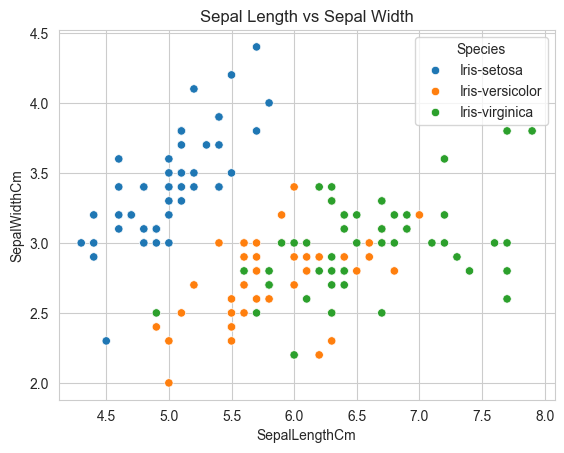

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style for graphs
sns.set_style("whitegrid")

# Scatter plot
sns.scatterplot(
    x="SepalLengthCm",
    y="SepalWidthCm",
    hue="Species",
    data=df
)

plt.title("Sepal Length vs Sepal Width")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

# Features (inputs)
X = df.drop(["Id", "Species"], axis=1)

# Target (output)
y = df["Species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: str


In [8]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [9]:
from sklearn.tree import DecisionTreeClassifier

# Create model
model = DecisionTreeClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:
from sklearn.metrics import accuracy_score

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


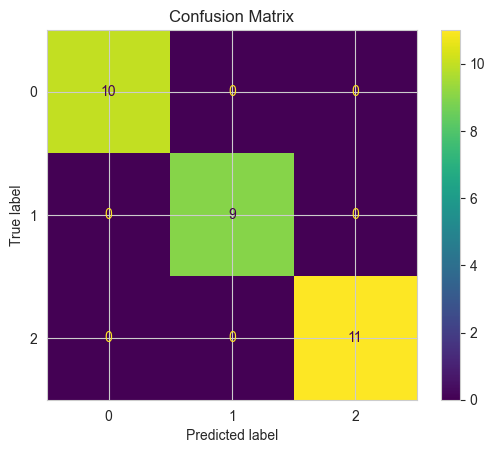

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [12]:
predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

predictions.head(10)

,Actual,Predicted
73,Iris-versicolor,Iris-versicolor
18,Iris-setosa,Iris-setosa
118,Iris-virginica,Iris-virginica
78,Iris-versicolor,Iris-versicolor
76,Iris-versicolor,Iris-versicolor
31,Iris-setosa,Iris-setosa
64,Iris-versicolor,Iris-versicolor
141,Iris-virginica,Iris-virginica
68,Iris-versicolor,Iris-versicolor
82,Iris-versicolor,Iris-versicolor


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 1.0


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [16]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(importance.sort_values(
    by="Importance",
    ascending=False
))

         Feature  Importance
2  PetalLengthCm    0.906143
3   PetalWidthCm    0.077186
1   SepalWidthCm    0.016670
0  SepalLengthCm    0.000000


In [18]:
import pandas as pd

sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
)

prediction = model.predict(sample)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa


# Conclusion

In this project, the Iris dataset was analyzed and used to build a machine learning classification model. Exploratory Data Analysis (EDA) was performed using statistical summaries and visualizations to understand the relationships between flower measurements.

A Decision Tree Classifier was trained using sepal and petal measurements to classify flowers into three species: Iris-setosa, Iris-versicolor, and Iris-virginica.

The model achieved 100% accuracy on the test dataset. Performance evaluation using the confusion matrix and classification report showed perfect precision, recall, and F1-score for all three classes.

Feature importance analysis indicated that petal measurements played the most significant role in species classification. The trained model was also tested on new flower measurements and successfully predicted the correct species.

This project demonstrates the complete machine learning workflow including data exploration, visualization, model training, evaluation, and prediction.
